In [5]:
!pip install tokenizer

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     |████████████████████████████████| 113 kB 1.8 MB/s eta 0:00:01


## Machine Learning for Sentiment Classification

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import re

file_path = 'Final_dataset.xlsx'
data = pd.read_excel(file_path)

def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower().strip()
    return text

data['Body'] = data['Body'].apply(preprocess_text)

label_encoder = LabelEncoder()
data['Encoded_Label'] = label_encoder.fit_transform(data['Label'])

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data['Body'])
y = data['Encoded_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1811
)

models = {
    "SVM": SVC(random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier()
}

param_grids = {
    "SVM": {
        'C': [0.01, 0.1, 1, 10, 100],
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'degree': [2, 3, 4, 5],
        'gamma': ['scale', 'auto']
    },
    "Naive Bayes": {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5],
        'max_features': ['sqrt', 'log2']
    },
    "Decision Tree": {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5],
        'max_features': ['sqrt', 'log2', None]
    },
    "Logistic Regression": {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'],
        'max_iter': [1000]
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 11, 15],
        'p': [1, 2]
    }
}

from sklearn.model_selection import GridSearchCV

cv_folds = 5

best_models = {}

for model_name, model in models.items():
    print(f"{"="*25} {model_name} {"="*25}")
    
    if model_name not in param_grids:
        print(f"No param grid defined for {model_name}, skipping...")
        continue
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        scoring='accuracy',
        cv=cv_folds,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"Best Params for {model_name}: {grid_search.best_params_}")
    print(f"Best CV Accuracy for {model_name}: {grid_search.best_score_:.4f}")
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"{model_name} Test Accuracy: {test_acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    print("-" * 60)
    
    best_models[model_name] = best_model

========================= SVM =========================
Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Params for SVM: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy for SVM: 0.7717
SVM Test Accuracy: 0.7870
Classification Report:
              precision    recall  f1-score   support

       anger       0.79      0.96      0.86       634
        fear       0.80      0.48      0.60       218
     sadness       0.74      0.23      0.35        73

    accuracy                           0.79       925
   macro avg       0.78      0.56      0.61       925
weighted avg       0.79      0.79      0.76       925

------------------------------------------------------------
========================= Naive Bayes =========================
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params for Naive Bayes: {'alpha': 0.1}
Best CV Accuracy for Naive Bayes: 0.7479
Naive Bayes Test Accuracy: 0.7654
Classification Report:
          

## BERT 1 & BERT 2 for Sentiment Classification
- BERT 1: bert-base-uncased
- BERT 2: bertweet-base-sentiment-analysis

In [20]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.utils.tensorboard import SummaryWriter
import torch
import re
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    AdamW,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

seed_value = 1811
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

config = {
    'file_path': 'Final_dataset.xlsx',
    'max_len': 128,
    'batch_size': 16,
    'num_epochs': 3,
    'learning_rate': 5e-5,
    'bert_model_name': 'bert-base-uncased',
    'bertweet_model_name': 'bertweet-base-sentiment-analysis',
    'output_dir': './results',
    'logging_dir': './logs',
    'save_steps': 500,
    'logging_steps': 100
}

def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower().strip()
    return text

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]
        encoding = self.tokenizer.encode_plus(
            text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            add_special_tokens=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

data = pd.read_excel(config['file_path'])
data['Body'] = data['Body'].apply(preprocess_text)

label_encoder = LabelEncoder()
data['Encoded_Label'] = label_encoder.fit_transform(data['Label'])

train_texts, test_texts, train_labels, test_labels = train_test_split(
    data['Body'],
    data['Encoded_Label'],
    test_size=0.2,
    random_state=33
)

def create_dataloaders(tokenizer, batch_size):
    train_dataset = TextDataset(train_texts.tolist(), train_labels.tolist(), tokenizer, config['max_len'])
    test_dataset = TextDataset(test_texts.tolist(), test_labels.tolist(), tokenizer, config['max_len'])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def train_model(model, train_loader, optimizer, device, num_epochs, scheduler=None, writer=None, run_name=""):
    model.train()
    
    global_step = 0
    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        total = 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if scheduler is not None:
                scheduler.step()

            total_loss += loss.item()
            
            if writer is not None:
                writer.add_scalar(f"{run_name}/train_loss", loss.item(), global_step)
                
                if scheduler is not None:
                    current_lr = scheduler.get_last_lr()[0]
                else:
                    current_lr = optimizer.param_groups[0]['lr']
                
                writer.add_scalar(f"{run_name}/learning_rate", current_lr, global_step)
            
            global_step += 1
            loop.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        epoch_acc = 100.0 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Acc: {epoch_acc:.2f}%")

        if writer is not None:
            writer.add_scalar(f"{run_name}/epoch_loss", avg_loss, epoch)
            writer.add_scalar(f"{run_name}/epoch_accuracy", epoch_acc, epoch)

    return model

def test_model(model, test_loader, device):
    model.eval()
    y_pred = []
    y_true = []
    loop = tqdm(test_loader, desc="Testing")
    with torch.no_grad():
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            y_pred.extend(predictions.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    return y_true, y_pred

bert_tokenizer = BertTokenizer.from_pretrained(config['bert_model_name'])
bert_model = BertForSequenceClassification.from_pretrained(
    config['bert_model_name'],
    num_labels=len(data['Encoded_Label'].unique())
)

local_model_path = "bertweet-base-sentiment-analysis"
bertweet_tokenizer = AutoTokenizer.from_pretrained(local_model_path, use_fast=False, normalization=True)
bertweet_model = AutoModelForSequenceClassification.from_pretrained(
    local_model_path,
    num_labels=len(data['Encoded_Label'].unique()),
    ignore_mismatched_sizes=True
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)
bertweet_model = bertweet_model.to(device)

bert_optimizer = AdamW(bert_model.parameters(), lr=config['learning_rate'], weight_decay=1e-2)
bertweet_optimizer = AdamW(bertweet_model.parameters(), lr=config['learning_rate'], weight_decay=1e-2)

bert_train_loader, bert_test_loader = create_dataloaders(bert_tokenizer, config['batch_size'])
bertweet_train_loader, bertweet_test_loader = create_dataloaders(bertweet_tokenizer, config['batch_size'])

bert_total_steps = len(bert_train_loader) * config['num_epochs']
bert_warmup_steps = int(0.1 * bert_total_steps)
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps=bert_warmup_steps,
    num_training_steps=bert_total_steps
)

bertweet_total_steps = len(bertweet_train_loader) * config['num_epochs']
bertweet_warmup_steps = int(0.1 * bertweet_total_steps)
bertweet_scheduler = get_linear_schedule_with_warmup(
    bertweet_optimizer,
    num_warmup_steps=bertweet_warmup_steps,
    num_training_steps=bertweet_total_steps
)

writer = SummaryWriter(log_dir=config['logging_dir'])

print("Training BERT...")
train_model(
    bert_model,
    bert_train_loader,
    bert_optimizer,
    device,
    config['num_epochs'],
    scheduler=bert_scheduler,
    writer=writer,
    run_name="BERT"
)
bert_y_true, bert_y_pred = test_model(bert_model, bert_test_loader, device)

print("\nTraining BERTweet...")
train_model(
    bertweet_model,
    bertweet_train_loader,
    bertweet_optimizer,
    device,
    config['num_epochs'],
    scheduler=bertweet_scheduler,
    writer=writer,
    run_name="BERTweet"
)
bertweet_y_true, bertweet_y_pred = test_model(bertweet_model, bertweet_test_loader, device)

hparam_dict = {
    'max_len': config['max_len'],
    'batch_size': config['batch_size'],
    'num_epochs': config['num_epochs'],
    'learning_rate': config['learning_rate']
}

metric_dict_bert = {
    'BERT_test_accuracy': accuracy_score(bert_y_true, bert_y_pred)
}
metric_dict_bertweet = {
    'BERTweet_test_accuracy': accuracy_score(bertweet_y_true, bertweet_y_pred)
}

writer.add_hparams(hparam_dict, metric_dict_bert)
writer.add_hparams(hparam_dict, metric_dict_bertweet)

writer.close()

print("\nBERT Classification Report:\n", classification_report(bert_y_true, bert_y_pred, target_names=label_encoder.classes_))
print("BERT Test Accuracy:", accuracy_score(bert_y_true, bert_y_pred))

print("\nBERTweet Classification Report:\n", classification_report(bertweet_y_true, bertweet_y_pred, target_names=label_encoder.classes_))
print("BERTweet Test Accuracy:", accuracy_score(bertweet_y_true, bertweet_y_pred))


/root/miniconda3/lib/python3.8/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
/root/miniconda3/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch 

Training BERT...


Epoch 1/3: 100%|██████████| 232/232 [00:14<00:00, 16.22it/s, loss=0.212]


Epoch 1/3, Loss: 0.6352, Acc: 73.65%


Epoch 2/3: 100%|██████████| 232/232 [00:14<00:00, 16.14it/s, loss=0.904] 


...

Epoch 2/3, Loss: 0.2638, Acc: 89.72%


Epoch 3/3: 100%|██████████| 232/232 [00:12<00:00, 18.15it/s, loss=0.00595]


Epoch 3/3, Loss: 0.0831, Acc: 97.21%


Testing: 100%|██████████| 58/58 [00:01<00:00, 48.03it/s]


BERT Classification Report:
               precision    recall  f1-score   support

       anger       0.88      0.91      0.90       627
        fear       0.77      0.75      0.76       208
     sadness       0.71      0.61      0.65        90

    accuracy                           0.84       925
   macro avg       0.79      0.76      0.77       925
weighted avg       0.84      0.84      0.84       925

BERT Test Accuracy: 0.8432432432432433

BERTweet Classification Report:
               precision    recall  f1-score   support

       anger       0.90      0.94      0.92       627
        fear       0.79      0.77      0.78       208
     sadness       0.83      0.63      0.72        90

    accuracy                           0.87       925
   macro avg       0.84      0.78      0.81       925
weighted avg       0.87      0.87      0.87       925

BERTweet Test Accuracy: 0.8702702702702703


## BERT 3 (bert-base-uncased-emotion) for Sentiment Classification

In [22]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import torch
import re
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    AdamW,
    get_linear_schedule_with_warmup
)

seed_value = 1811
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

config = {
    'file_path': 'Final_dataset.xlsx',
    'max_len': 128,
    'batch_size': 64,
    'num_epochs': 8,
    'learning_rate': 2e-5,
    'model_name': 'bert-base-uncased-emotion',  
    'output_dir': './results',        
    'logging_dir': './logs',          
    'save_steps': 500,                
    'logging_steps': 100              
}

def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower().strip()
    return text

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]
        encoding = self.tokenizer.encode_plus(
            text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            add_special_tokens=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

data = pd.read_excel(config['file_path'])
data['Body'] = data['Body'].apply(preprocess_text)

label_encoder = LabelEncoder()
data['Encoded_Label'] = label_encoder.fit_transform(data['Label'])

train_texts, test_texts, train_labels, test_labels = train_test_split(
    data['Body'], 
    data['Encoded_Label'], 
    test_size=0.2,
    random_state=33
)

def create_dataloaders(tokenizer, batch_size):
    train_dataset = TextDataset(train_texts.tolist(), train_labels.tolist(), tokenizer, config['max_len'])
    test_dataset = TextDataset(test_texts.tolist(), test_labels.tolist(), tokenizer, config['max_len'])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def train_model(model, train_loader, optimizer, device, num_epochs, scheduler=None):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if scheduler is not None:
                scheduler.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch+1}/{num_epochs}, Total Loss: {total_loss:.4f}")

def test_model(model, test_loader, device):
    model.eval()
    y_pred = []
    y_true = []
    loop = tqdm(test_loader, desc="Testing")
    with torch.no_grad():
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            y_pred.extend(predictions.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    return y_true, y_pred

tokenizer = AutoTokenizer.from_pretrained(config['model_name'], use_fast=False, normalization=True)
model = AutoModelForSequenceClassification.from_pretrained(
    config['model_name'],
    num_labels=len(data['Encoded_Label'].unique()),
    ignore_mismatched_sizes=True
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=1e-2)

total_steps = (len(train_texts) // config['batch_size'] + 1) * config['num_epochs']
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

train_loader, test_loader = create_dataloaders(tokenizer, config['batch_size'])

print(f"Training the {config['model_name']} model...")
train_model(model, train_loader, optimizer, device, config['num_epochs'], scheduler=scheduler)

y_true, y_pred = test_model(model, test_loader, device)

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_encoder.classes_))


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased-emotion and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([6]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([6, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/root/miniconda3/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training the bert-base-uncased-emotion model...


Epoch 1/8: 100%|██████████| 58/58 [00:11<00:00,  5.01it/s, loss=0.606]


Epoch 1/8, Total Loss: 47.0511


Epoch 2/8: 100%|██████████| 58/58 [00:11<00:00,  5.01it/s, loss=0.352]


...

Epoch 7/8, Total Loss: 4.1266


Epoch 8/8: 100%|██████████| 58/58 [00:11<00:00,  4.99it/s, loss=0.0224]


Epoch 8/8, Total Loss: 3.3824


Testing: 100%|██████████| 15/15 [00:01<00:00,  9.57it/s]


Classification Report:
               precision    recall  f1-score   support

       anger       0.89      0.90      0.90       627
        fear       0.76      0.77      0.77       208
     sadness       0.73      0.62      0.67        90

    accuracy                           0.85       925
   macro avg       0.79      0.77      0.78       925
weighted avg       0.85      0.85      0.85       925



## Bar Chart of Overall Model Performance Evaluation

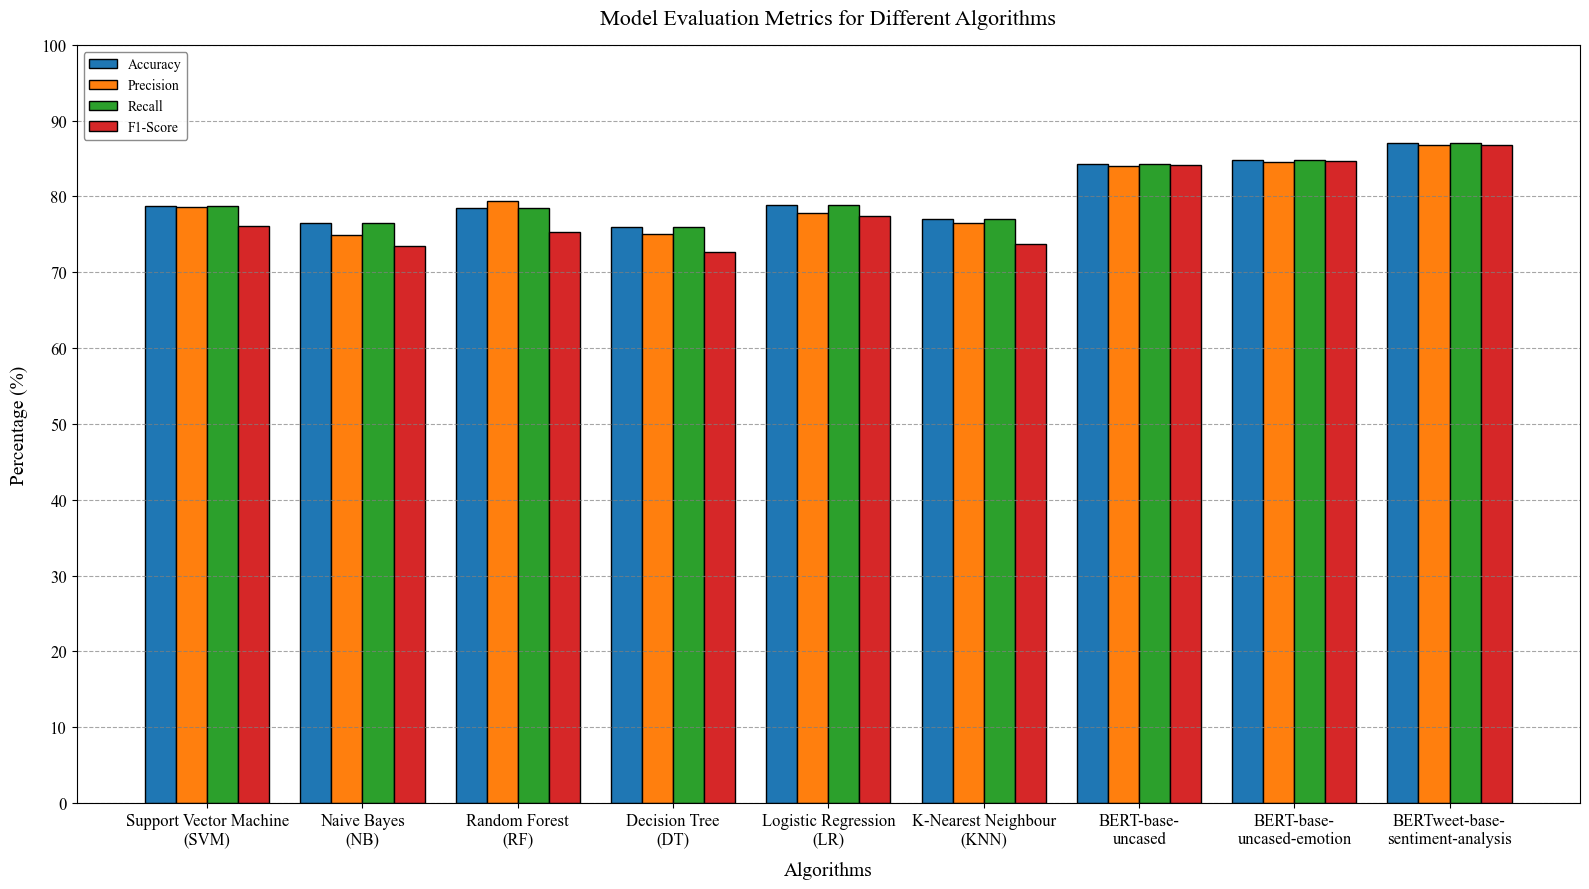

In [10]:
import matplotlib.pyplot as plt
import numpy as np

algorithms = [
    "Support Vector Machine\n(SVM)",
    "Naive Bayes\n(NB)",
    "Random Forest\n(RF)",
    "Decision Tree\n(DT)",
    "Logistic Regression\n(LR)",
    "K-Nearest Neighbour\n(KNN)",
    "BERT-base-\nuncased",
    "BERT-base-\nuncased-emotion",
    "BERTweet-base-\nsentiment-analysis"
]
accuracy = [78.70, 76.54, 78.49, 76.00, 78.92, 76.97, 84.32, 84.76, 87.03]
precision = [78.60, 74.90, 79.43, 75.05, 77.80, 76.48, 84.05, 84.57, 86.80]
recall = [78.70, 76.54, 78.49, 76.00, 78.92, 76.97, 84.32, 84.76, 87.03]
f1_score = [76.10, 73.41, 75.31, 72.61, 77.38, 73.78, 84.15, 84.62, 86.76]

x = np.arange(len(algorithms))
width = 0.2

plt.figure(figsize=(16, 9))

plt.bar(x - width * 1.5, accuracy, width, label='Accuracy', edgecolor='black')
plt.bar(x - width / 2, precision, width, label='Precision', edgecolor='black')
plt.bar(x + width / 2, recall, width, label='Recall', edgecolor='black')
plt.bar(x + width * 1.5, f1_score, width, label='F1-Score', edgecolor='black')

plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
plt.yticks(np.arange(0, 101, 10), fontsize=12, fontname="Times New Roman")

plt.xticks(x, algorithms, rotation=0, fontsize=12, fontname="Times New Roman", ha='center')
plt.xlabel("Algorithms", fontsize=14, fontname="Times New Roman", labelpad=10)
plt.ylabel("Percentage (%)", fontsize=14, fontname="Times New Roman", labelpad=10)
plt.title("Model Evaluation Metrics for Different Algorithms", fontsize=16, fontname="Times New Roman", pad=15)

plt.legend(loc='upper left', fontsize=12, frameon=True, framealpha=0.9, edgecolor='gray', prop={'family': 'Times New Roman'})

plt.tight_layout()
plt.savefig("model_evaluation_metrics.svg", format="svg")
plt.show()